Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('darkgrid')

os.makedirs('plots', exist_ok=True)
print("All libraries imported successfully!")

All libraries imported successfully!


Load & Explore Dataset

In [2]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


In [3]:
print("Missing values:")
print(df.isnull().sum())
print("\nBrand distribution:")
print(df['brand'].value_counts())
print("\nFuel types:")
print(df['fuelType'].value_counts())

Missing values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
mpg             0
engineSize      0
brand           0
dtype: int64

Brand distribution:
brand
Ford          17676
Volkswagen    14529
Vauxhall      13089
Mercedes      12820
Audi          10409
Bmw           10274
Toyota         6548
Skoda          6091
Hyundai        4689
Name: count, dtype: int64

Fuel types:
fuelType
Petrol      53245
Diesel      39885
Hybrid       2991
Electric        4
Name: count, dtype: int64


Create Target Variable

We divide prices into 3 categories:
Budget: 0 – 10,000
Mid-Range: 10,000 – 20,000
Premium: 20,000 – 100,000

Category distribution:
  Budget (0): 24,981 cars (26.0%)
  Mid-Range (1): 46,472 cars (48.3%)
  Premium (2): 24,672 cars (25.7%)


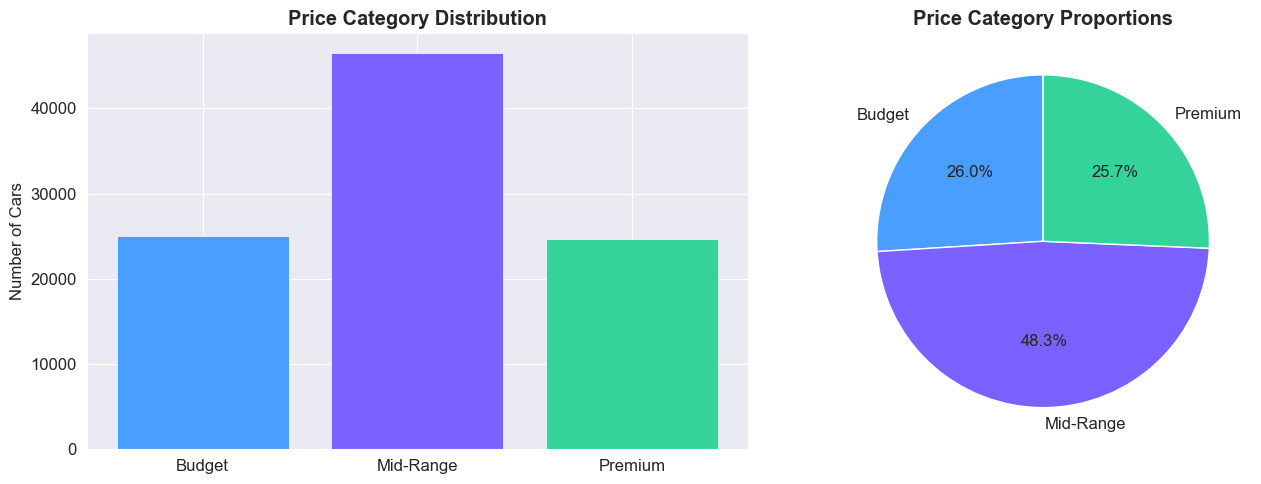

Target variable created!


In [4]:
bins   = [0, 10000, 20000, 100000]
labels = [0, 1, 2]
df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels).astype(int)

label_names = {0: 'Budget', 1: 'Mid-Range', 2: 'Premium'}

print("Category distribution:")
counts = df['price_category'].value_counts().sort_index()
for cat, count in counts.items():
    print(f"  {label_names[cat]} ({cat}): {count:,} cars ({count/len(df)*100:.1f}%)")

colors = ['#4a9eff', '#7b61ff', '#34d399']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([label_names[i] for i in sorted(counts.index)],
            [counts[i] for i in sorted(counts.index)],
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Price Category Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Cars')

axes[1].pie([counts[i] for i in sorted(counts.index)],
            labels=[label_names[i] for i in sorted(counts.index)],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Price Category Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Target variable created!")

Preprocessing & Feature Engineering

In [5]:
df_ml = df.copy()

# Car age
df_ml['car_age'] = df_ml['year'].max() - df_ml['year'] 
df_ml = df_ml.drop(columns=['year'])

# Log transform mileage
df_ml['mileage'] = np.log1p(df_ml['mileage'])

# One-hot encode
df_ml = pd.get_dummies(df_ml, columns=['brand', 'model', 'fuelType', 'transmission'], drop_first=False)

print("Shape after encoding:", df_ml.shape)

X = df_ml.drop(columns=['price', 'price_category'])
y = df_ml['price_category']

print("Features:", X.shape[1])
print("Target classes:", sorted(y.unique()))

Shape after encoding: (96125, 215)
Features: 213
Target classes: [np.int64(0), np.int64(1), np.int64(2)]


Train/Test Split & Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ['mileage', 'engineSize', 'mpg', 'car_age']
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"Features:      {X_train.shape[1]}")

Training set:  76,900 rows
Test set:      19,225 rows
Features:      213


Feature Selection

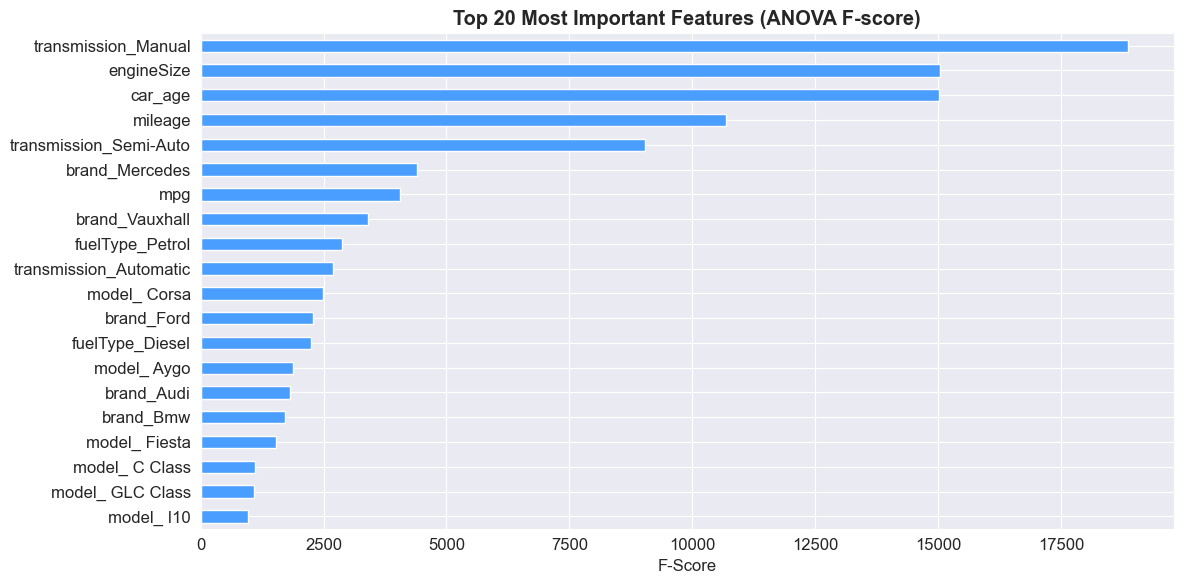

Top 10 features:
  transmission_Manual: 18855.3
  engineSize: 15040.1
  car_age: 15017.1
  mileage: 10687.9
  transmission_Semi-Auto: 9035.0
  brand_Mercedes: 4393.0
  mpg: 4048.5
  brand_Vauxhall: 3395.7
  fuelType_Petrol: 2881.5
  transmission_Automatic: 2699.5

Feature counts: All=213, Top50=50, Top20=20


In [7]:

# Select top 50 features
selector_50 = SelectKBest(f_classif, k=50)
X_train_50 = selector_50.fit_transform(X_train, y_train)
X_test_50  = selector_50.transform(X_test)

# Select top 20 features
selector_20 = SelectKBest(f_classif, k=20)
X_train_20 = selector_20.fit_transform(X_train, y_train)
X_test_20  = selector_20.transform(X_test)

# Show top 20 most important features
feature_scores = pd.Series(selector_50.scores_, index=X_train.columns)
top_features = feature_scores.nlargest(20)

plt.figure(figsize=(12, 6))
top_features.sort_values().plot(kind='barh', color='#4a9eff', edgecolor='white')
plt.title('Top 20 Most Important Features (ANOVA F-score)', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('plots/02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
for feat, score in feature_scores.nlargest(10).items():
    print(f"  {feat}: {score:.1f}")

configs = ['All Features', 'Top 50', 'Top 20']
print(f"\nFeature counts: All={X_train.shape[1]}, Top50=50, Top20=20")

Logistic Regression (Linear Classifier)

In [8]:
# Baseline Logistic Regression
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
lr_base_pred = lr_base.predict(X_test)

print("Baseline Logistic Regression Results:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_base_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_base_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_base_pred, average='weighted'):.4f}")
print(f"  F1:        {f1_score(y_test, lr_base_pred, average='weighted'):.4f}")

Baseline Logistic Regression Results:
  Accuracy:  0.8867
  Precision: 0.8871
  Recall:    0.8867
  F1:        0.8867


In [9]:
param_grid_lr = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'solver':   ['lbfgs', 'saga'],
    'penalty':  ['l2'],
    'max_iter': [1000]
}

print("Running GridSearchCV for Logistic Regression...")
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train, y_train)

print(f"\nBest parameters: {grid_lr.best_params_}")
print(f"Best CV F1 score: {grid_lr.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 score: 0.8854


=== Best Logistic Regression (Tuned) ===
              precision    recall  f1-score   support

      Budget       0.90      0.86      0.88      4996
   Mid-Range       0.87      0.90      0.88      9295
     Premium       0.90      0.89      0.90      4934

    accuracy                           0.89     19225
   macro avg       0.89      0.88      0.89     19225
weighted avg       0.89      0.89      0.89     19225



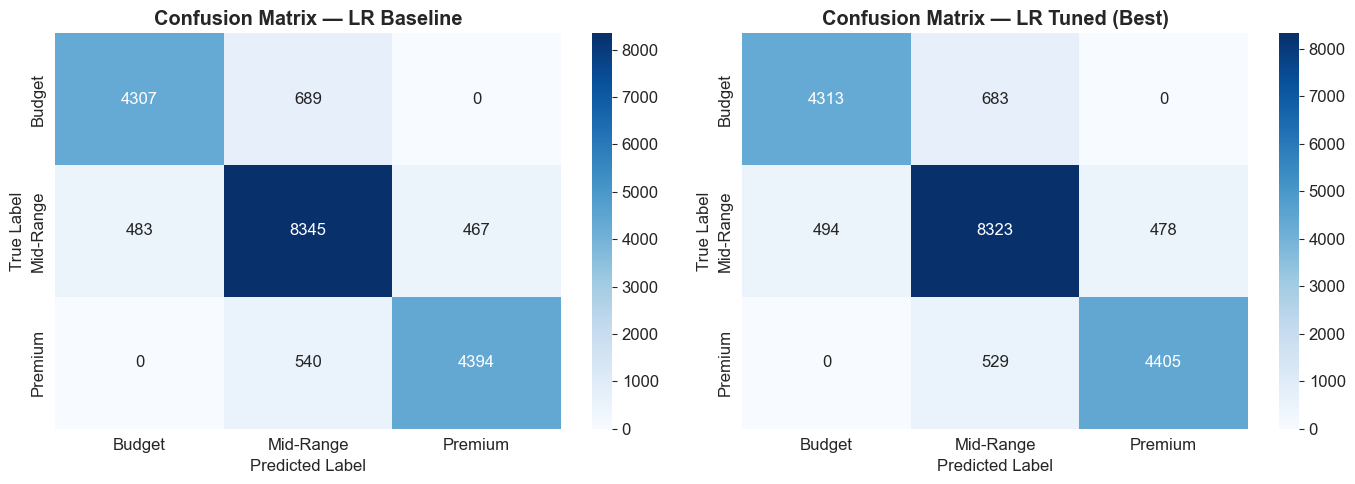

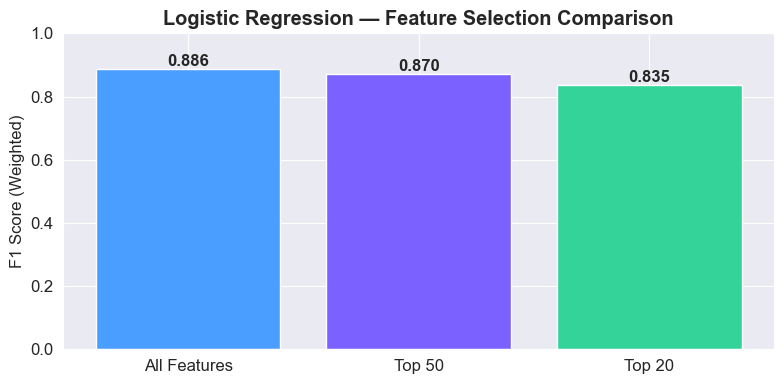

Final — Accuracy: 0.8864 | Precision: 0.8867 | Recall: 0.8864 | F1: 0.8864


In [10]:
# Evaluate best Logistic Regression
lr_best = grid_lr.best_estimator_
lr_pred = lr_best.predict(X_test)

print("=== Best Logistic Regression (Tuned) ===")
print(classification_report(y_test, lr_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

# Confusion matrix — baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (lr_base_pred, 'LR Baseline'),
    (lr_pred,      'LR Tuned (Best)')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/03_lr_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature selection comparison
lr_scores = []
for Xtr, Xte in [(X_train, X_test), (X_train_50, X_test_50), (X_train_20, X_test_20)]:
    m = LogisticRegression(**{k: v for k, v in grid_lr.best_params_.items()}, random_state=42)
    m.fit(Xtr, y_train)
    lr_scores.append(f1_score(y_test, m.predict(Xte), average='weighted'))

plt.figure(figsize=(8, 4))
plt.bar(configs, lr_scores, color=['#4a9eff', '#7b61ff', '#34d399'], edgecolor='white')
plt.title('Logistic Regression — Feature Selection Comparison', fontweight='bold')
plt.ylabel('F1 Score (Weighted)')
plt.ylim(0, 1)
for i, v in enumerate(lr_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_lr_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall    = recall_score(y_test, lr_pred, average='weighted')
lr_f1        = f1_score(y_test, lr_pred, average='weighted')
print(f"Final — Accuracy: {lr_accuracy:.4f} | Precision: {lr_precision:.4f} | Recall: {lr_recall:.4f} | F1: {lr_f1:.4f}")

KNN (Distance-Based Classifier)

In [11]:
# Baseline KNN
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_50, y_train)   # using Top 50 features
knn_base_pred = knn_base.predict(X_test_50)

print("=== Baseline KNN (default k=5, Top 50 features) ===")
print(f"Accuracy:  {accuracy_score(y_test, knn_base_pred):.4f}")
print(f"Precision: {precision_score(y_test, knn_base_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, knn_base_pred, average='weighted'):.4f}")
print(f"F1:        {f1_score(y_test, knn_base_pred, average='weighted'):.4f}")

=== Baseline KNN (default k=5, Top 50 features) ===
Accuracy:  0.8982
Precision: 0.8983
Recall:    0.8982
F1:        0.8982


In [12]:
# KNN Hyperparameter Tuning
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

print("Running GridSearchCV for KNN...")
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train_50, y_train)

print(f"\nBest parameters: {grid_knn.best_params_}")
print(f"Best CV F1 score: {grid_knn.best_score_:.4f}")

Running GridSearchCV for KNN...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV F1 score: 0.8983


=== Best KNN (Tuned) ===
              precision    recall  f1-score   support

      Budget       0.91      0.89      0.90      4996
   Mid-Range       0.89      0.91      0.90      9295
     Premium       0.91      0.90      0.91      4934

    accuracy                           0.90     19225
   macro avg       0.90      0.90      0.90     19225
weighted avg       0.90      0.90      0.90     19225



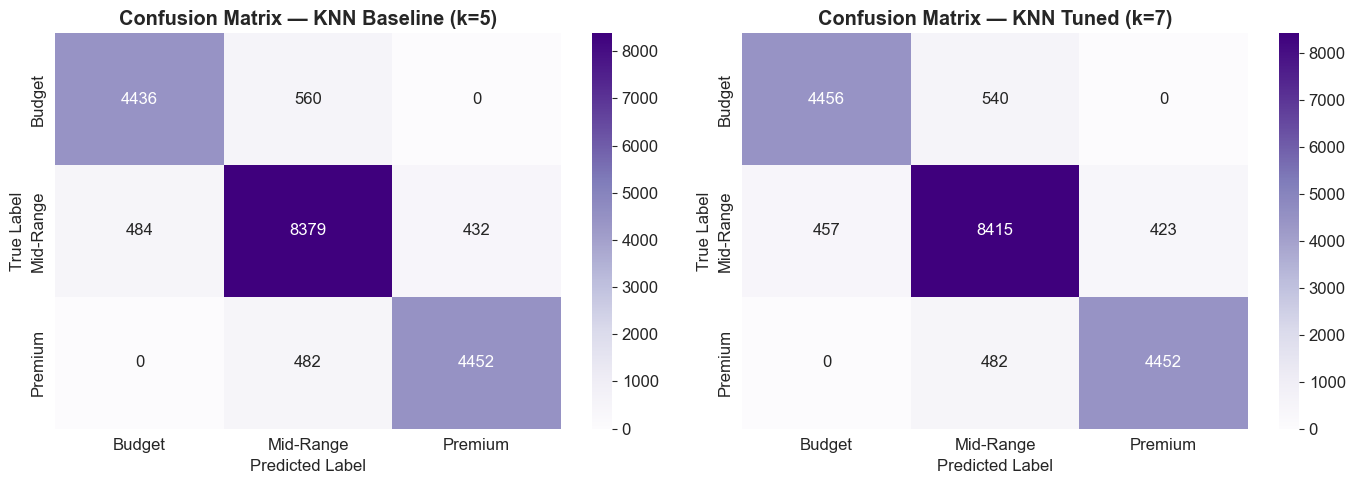

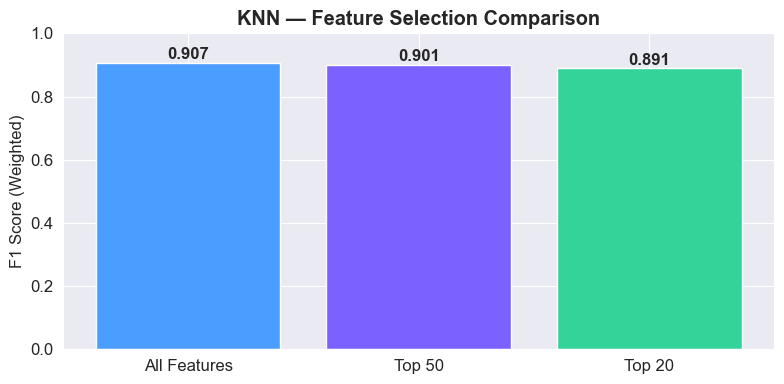

Final — Accuracy: 0.9011 | Precision: 0.9012 | Recall: 0.9011 | F1: 0.9011


In [13]:
# Evaluate best KNN
knn_best = grid_knn.best_estimator_
knn_best_pred = knn_best.predict(X_test_50)

print("=== Best KNN (Tuned) ===")
print(classification_report(y_test, knn_best_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

# Confusion matrix — baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (knn_base_pred, 'KNN Baseline (k=5)'),
    (knn_best_pred, f"KNN Tuned (k={grid_knn.best_params_['n_neighbors']})")
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/05_knn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature selection comparison
knn_scores = []
for Xtr, Xte in [(X_train, X_test), (X_train_50, X_test_50), (X_train_20, X_test_20)]:
    m = KNeighborsClassifier(**grid_knn.best_params_)
    m.fit(Xtr, y_train)
    knn_scores.append(f1_score(y_test, m.predict(Xte), average='weighted'))

plt.figure(figsize=(8, 4))
plt.bar(configs, knn_scores, color=['#4a9eff', '#7b61ff', '#34d399'], edgecolor='white')
plt.title('KNN — Feature Selection Comparison', fontweight='bold')
plt.ylabel('F1 Score (Weighted)')
plt.ylim(0, 1)
for i, v in enumerate(knn_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_knn_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

knn_accuracy  = accuracy_score(y_test, knn_best_pred)
knn_precision = precision_score(y_test, knn_best_pred, average='weighted')
knn_recall    = recall_score(y_test, knn_best_pred, average='weighted')
knn_f1        = f1_score(y_test, knn_best_pred, average='weighted')
print(f"Final — Accuracy: {knn_accuracy:.4f} | Precision: {knn_precision:.4f} | Recall: {knn_recall:.4f} | F1: {knn_f1:.4f}")

Random Forest (Ensemble Tree Classifier)

In [14]:
# Baseline Random Forest
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)

print("=== Baseline Random Forest ===")
print(f"  Accuracy:  {accuracy_score(y_test, rf_base_pred):.4f}")
print(f"  Precision: {precision_score(y_test, rf_base_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, rf_base_pred, average='weighted'):.4f}")
print(f"  F1:        {f1_score(y_test, rf_base_pred, average='weighted'):.4f}")

=== Baseline Random Forest ===
  Accuracy:  0.9002
  Precision: 0.9002
  Recall:    0.9002
  F1:        0.9002


In [15]:
# Hyperparameter tuning with GridSearchCV
param_grid_rf = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_split':[2, 5],
}

print("Running GridSearchCV for Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"\nBest parameters: {grid_rf.best_params_}")
print(f"Best CV F1 score: {grid_rf.best_score_:.4f}")


Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.9087


=== Best Random Forest (Tuned) ===
              precision    recall  f1-score   support

      Budget       0.91      0.89      0.90      4996
   Mid-Range       0.90      0.91      0.91      9295
     Premium       0.92      0.92      0.92      4934

    accuracy                           0.91     19225
   macro avg       0.91      0.91      0.91     19225
weighted avg       0.91      0.91      0.91     19225



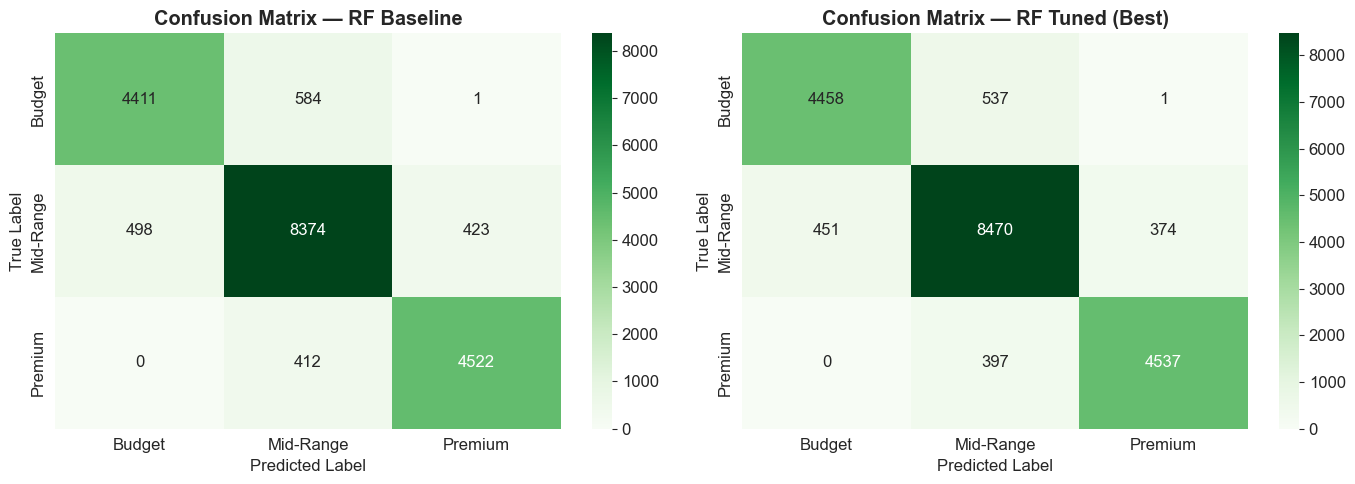

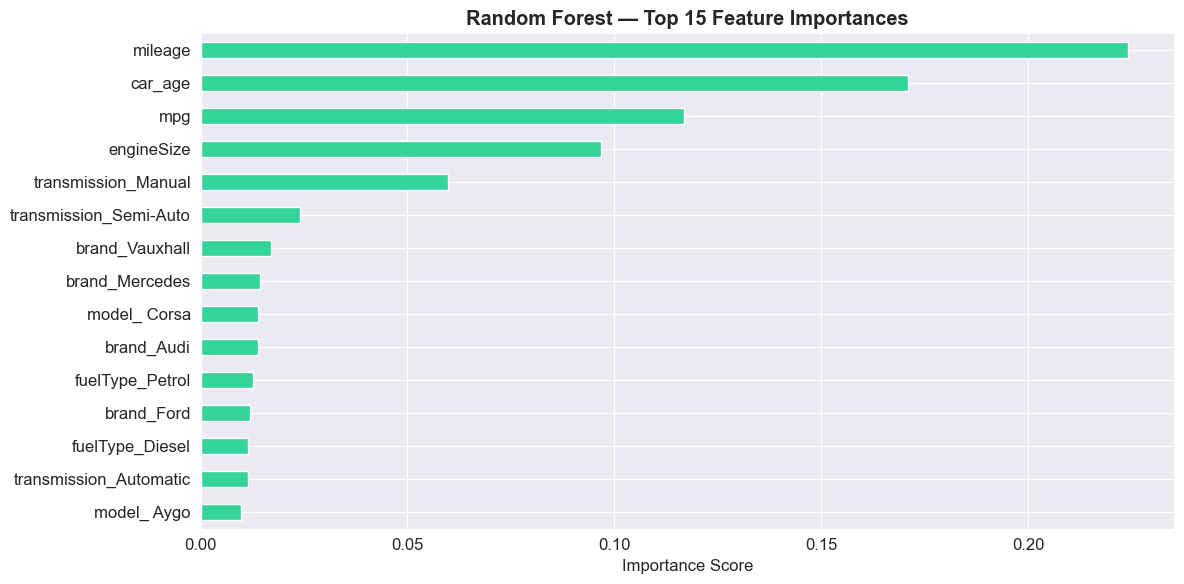

Final — Accuracy: 0.9085 | Precision: 0.9085 | Recall: 0.9085 | F1: 0.9084


In [16]:
# Evaluate best Random Forest
rf_best = grid_rf.best_estimator_
rf_pred = rf_best.predict(X_test)

print("=== Best Random Forest (Tuned) ===")
print(classification_report(y_test, rf_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (rf_base_pred, 'RF Baseline'),
    (rf_pred,      'RF Tuned (Best)')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/07_rf_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance from Random Forest
importances = pd.Series(rf_best.feature_importances_, index=X_train.columns)
top_rf = importances.nlargest(15)

plt.figure(figsize=(12, 6))
top_rf.sort_values().plot(kind='barh', color='#34d399', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/08_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall    = recall_score(y_test, rf_pred, average='weighted')
rf_f1        = f1_score(y_test, rf_pred, average='weighted')
print(f"Final — Accuracy: {rf_accuracy:.4f} | Precision: {rf_precision:.4f} | Recall: {rf_recall:.4f} | F1: {rf_f1:.4f}")


XGBoost (Gradient Boosting Classifier)

In [17]:
# Baseline XGBoost
xgb_base = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                          eval_metric='mlogloss', verbosity=0)
xgb_base.fit(X_train, y_train)
xgb_base_pred = xgb_base.predict(X_test)

print("=== Baseline XGBoost ===")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_base_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_base_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, xgb_base_pred, average='weighted'):.4f}")
print(f"  F1:        {f1_score(y_test, xgb_base_pred, average='weighted'):.4f}")


=== Baseline XGBoost ===
  Accuracy:  0.9132
  Precision: 0.9133
  Recall:    0.9132
  F1:        0.9132


In [18]:
# Hyperparameter tuning with GridSearchCV
param_grid_xgb = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [4, 6, 8],
}

print("Running GridSearchCV for XGBoost...")
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0),
    param_grid_xgb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

print(f"\nBest parameters: {grid_xgb.best_params_}")
print(f"Best CV F1 score: {grid_xgb.best_score_:.4f}")


Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}
Best CV F1 score: 0.9151


=== Best XGBoost (Tuned) ===
              precision    recall  f1-score   support

      Budget       0.92      0.90      0.91      4996
   Mid-Range       0.91      0.92      0.91      9295
     Premium       0.93      0.92      0.92      4934

    accuracy                           0.92     19225
   macro avg       0.92      0.91      0.92     19225
weighted avg       0.92      0.92      0.92     19225



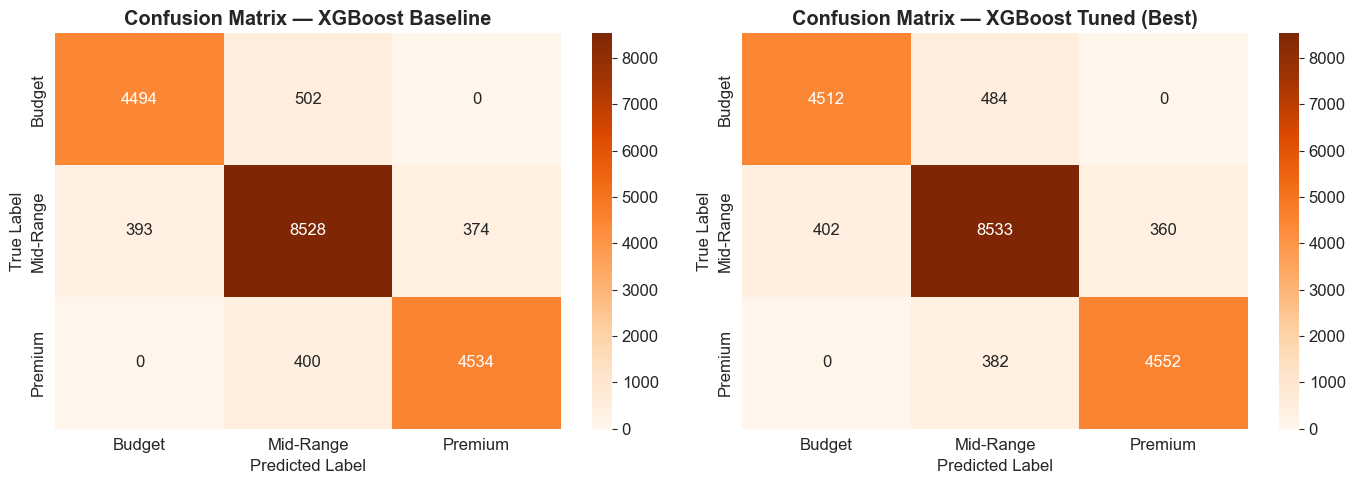

Final — Accuracy: 0.9153 | Precision: 0.9154 | Recall: 0.9153 | F1: 0.9153


In [19]:
# Evaluate best XGBoost
xgb_best = grid_xgb.best_estimator_
xgb_pred = xgb_best.predict(X_test)

print("=== Best XGBoost (Tuned) ===")
print(classification_report(y_test, xgb_pred, target_names=['Budget', 'Mid-Range', 'Premium']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = ['Budget', 'Mid-Range', 'Premium']

for ax, (preds, title) in zip(axes, [
    (xgb_base_pred, 'XGBoost Baseline'),
    (xgb_pred,      'XGBoost Tuned (Best)')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('plots/09_xgb_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

xgb_accuracy  = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average='weighted')
xgb_recall    = recall_score(y_test, xgb_pred, average='weighted')
xgb_f1        = f1_score(y_test, xgb_pred, average='weighted')
print(f"Final — Accuracy: {xgb_accuracy:.4f} | Precision: {xgb_precision:.4f} | Recall: {xgb_recall:.4f} | F1: {xgb_f1:.4f}")


Final Comparison Table & Results

In [20]:
results = {
    'Model': [
        'LR Baseline', 'LR Tuned',
        'KNN Baseline', 'KNN Tuned',
        'RF Baseline', 'RF Tuned',
        'XGBoost Baseline', 'XGBoost Tuned'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_base_pred),  accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_base_pred), accuracy_score(y_test, knn_best_pred),
        accuracy_score(y_test, rf_base_pred),  accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_base_pred), accuracy_score(y_test, xgb_pred),
    ],
    'Precision': [
        precision_score(y_test, lr_base_pred,  average='weighted'),
        precision_score(y_test, lr_pred,        average='weighted'),
        precision_score(y_test, knn_base_pred,  average='weighted'),
        precision_score(y_test, knn_best_pred,  average='weighted'),
        precision_score(y_test, rf_base_pred,   average='weighted'),
        precision_score(y_test, rf_pred,        average='weighted'),
        precision_score(y_test, xgb_base_pred,  average='weighted'),
        precision_score(y_test, xgb_pred,       average='weighted'),
    ],
    'Recall': [
        recall_score(y_test, lr_base_pred,  average='weighted'),
        recall_score(y_test, lr_pred,        average='weighted'),
        recall_score(y_test, knn_base_pred,  average='weighted'),
        recall_score(y_test, knn_best_pred,  average='weighted'),
        recall_score(y_test, rf_base_pred,   average='weighted'),
        recall_score(y_test, rf_pred,        average='weighted'),
        recall_score(y_test, xgb_base_pred,  average='weighted'),
        recall_score(y_test, xgb_pred,       average='weighted'),
    ],
    'F1 (weighted)': [
        f1_score(y_test, lr_base_pred,  average='weighted'),
        f1_score(y_test, lr_pred,        average='weighted'),
        f1_score(y_test, knn_base_pred,  average='weighted'),
        f1_score(y_test, knn_best_pred,  average='weighted'),
        f1_score(y_test, rf_base_pred,   average='weighted'),
        f1_score(y_test, rf_pred,        average='weighted'),
        f1_score(y_test, xgb_base_pred,  average='weighted'),
        f1_score(y_test, xgb_pred,       average='weighted'),
    ],
    'Best Params': [
        'default', str(grid_lr.best_params_),
        'k=5, uniform, euclidean', str(grid_knn.best_params_),
        '100 trees, no limit', str(grid_rf.best_params_),
        '100 trees, lr=0.1', str(grid_xgb.best_params_),
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
results_df[['Accuracy','Precision','Recall','F1 (weighted)']] =     results_df[['Accuracy','Precision','Recall','F1 (weighted)']].round(4)

print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)
display(results_df)

results_df.to_csv('plots/final_results.csv')
print("\nResults saved to plots/final_results.csv")


FINAL RESULTS SUMMARY


,Accuracy,Precision,Recall,F1 (weighted),Best Params
Model,,,,,
LR Baseline,0.8867,0.8871,0.8867,0.8867,default
LR Tuned,0.8864,0.8867,0.8864,0.8864,"{'C': 100, 'max_iter': 1000, 'penalty': 'l2', ..."
KNN Baseline,0.8982,0.8983,0.8982,0.8982,"k=5, uniform, euclidean"
KNN Tuned,0.9011,0.9012,0.9011,0.9011,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei..."
RF Baseline,0.9002,0.9002,0.9002,0.9002,"100 trees, no limit"
RF Tuned,0.9085,0.9085,0.9085,0.9084,"{'max_depth': None, 'min_samples_split': 5, 'n..."
XGBoost Baseline,0.9132,0.9133,0.9132,0.9132,"100 trees, lr=0.1"
XGBoost Tuned,0.9153,0.9154,0.9153,0.9153,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti..."



Results saved to plots/final_results.csv


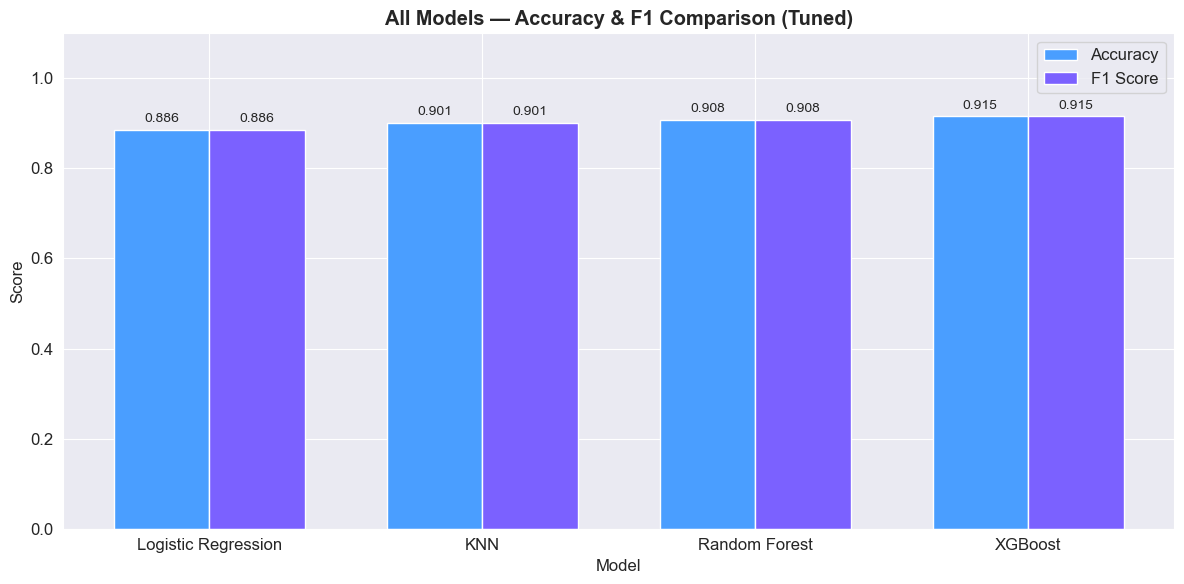


Best performing model: XGBoost (F1: 0.9153)


In [21]:
# Visual comparison of tuned models
models    = ['Logistic Regression', 'KNN', 'Random Forest', 'XGBoost']
accuracies = [lr_accuracy, knn_accuracy, rf_accuracy, xgb_accuracy]
f1_scores  = [lr_f1,       knn_f1,       rf_f1,       xgb_f1]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4a9eff', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Score', color='#7b61ff', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('All Models — Accuracy & F1 Comparison (Tuned)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('plots/10_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = f1_scores.index(max(f1_scores))
print(f"\nBest performing model: {models[best_idx]} (F1: {max(f1_scores):.4f})")
